In [17]:
# Observations stats 2.1 to 2.3

In [8]:
from __future__ import annotations

from pathlib import Path
import logging
from datetime import datetime, timezone
import pandas as pd
import numpy as np

# =============================================================================
# CONFIG
# =============================================================================
# All inputs are in the SAME folder:
OBS_DIR = Path(r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\ICST2026\2 - RQ2\Observations")

EPISODES_CSV = OBS_DIR / "List_Change_Episodes.csv"
MAIN_CSV = OBS_DIR / "5_Total_Repo.csv"  # optional if you copied it into Observations

# Outputs/logs
OUT_DIR = OBS_DIR / "Supporting_Stat"
OUT_DIR.mkdir(parents=True, exist_ok=True)
LOG_PATH = OUT_DIR / "rq2_stat_generator.log"

# Paper cutoff
CUTOFF_ISO = "2025-08-10 23:59:59+00:00"

# RQ2 scope filter (ONLY applied if timeline_scope exists in the episode CSV)
RQ2_TIMELINE_SCOPES = {"default_first_parent", "repo_wide"}

# 3-year bucket settings (chosen so you get a 2020–2022 bucket)
BUCKET_SIZE_YEARS = 3
BUCKET_ANCHOR_YEAR = 2020

CANON_STATES = ["Community", "Custom", "Mixed", "GMD", "ThirdParty"]
CANON_STYLES = ["Community", "Custom", "GMD", "ThirdParty"]

# =============================================================================
# Logging
# =============================================================================
def setup_logger() -> logging.Logger:
    logger = logging.getLogger("rq2")
    logger.setLevel(logging.INFO)
    logger.handlers.clear()

    fmt = logging.Formatter("%(asctime)s | %(levelname)s | %(message)s")

    sh = logging.StreamHandler()
    sh.setFormatter(fmt)
    logger.addHandler(sh)

    fh = logging.FileHandler(LOG_PATH, mode="w", encoding="utf-8")
    fh.setFormatter(fmt)
    logger.addHandler(fh)

    return logger

# =============================================================================
# Helpers
# =============================================================================
def find_col(df: pd.DataFrame, options: list[str]) -> str:
    low = {c.lower(): c for c in df.columns}
    for o in options:
        if o.lower() in low:
            return low[o.lower()]
    # substring fallback
    for o in options:
        for c in df.columns:
            if o.lower() in c.lower():
                return c
    raise KeyError(f"Could not find any of columns: {options}")

def find_col_optional(df: pd.DataFrame, options: list[str]) -> str | None:
    try:
        return find_col(df, options)
    except KeyError:
        return None

def parse_dt(x) -> pd.Timestamp:
    if x is None:
        return pd.NaT
    s = str(x).strip()
    if not s or s.lower() in {"nan", "nat", "none", "null"}:
        return pd.NaT
    s = s.replace("Z", "+00:00")
    return pd.to_datetime(s, utc=True, errors="coerce")

def normalize_token(x: str) -> str:
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return ""
    s = str(x).strip()
    if not s or s.lower() in {"nan", "none", "null"}:
        return ""

    low = s.lower().replace(" ", "").replace("-", "").replace("_", "")
    # tolerate Emu_* and plain labels
    if low in {"community", "emucommunity"} or "emucommunity" in low or "community" in low:
        return "Community"
    if low in {"custom", "emucustom"} or "emucustom" in low or "custom" in low:
        return "Custom"
    if low in {"gmd", "emugmd"} or "emugmd" in low or "gmd" in low:
        return "GMD"
    if low == "mixed":
        return "Mixed"
    if "third" in low:
        return "ThirdParty"
    return s

def parse_styleset(cell) -> list[str]:
    """
    Parses a cell that might be:
      - "Emu_Custom"
      - "Emu_Custom || Emu_Community"
      - "['Emu_Custom','GMD']"
      - "Custom+Community"
      - "Emu_Community+ThirdParty"
    and returns canonical style tokens among CANON_STYLES.
    """
    if cell is None or (isinstance(cell, float) and np.isnan(cell)):
        return []
    s = str(cell).strip()
    if not s or s.lower() in {"nan", "none", "null"}:
        return []

    s2 = s.replace("[", "").replace("]", "").replace("'", "").replace('"', "")

    parts = [s2]
    for sep in ["||", "|", "+", ",", ";", "/"]:
        if sep in s2:
            parts = [p.strip() for p in s2.split(sep)]
            break

    styles = [normalize_token(p) for p in parts]
    styles = [st for st in styles if st and st != "Mixed"]
    styles = [st for st in styles if st in CANON_STYLES]
    return sorted(set(styles))

def state_from_styles(styles: list[str]) -> str:
    styles = [s for s in styles if s in CANON_STYLES]
    if not styles:
        return ""
    return "Mixed" if len(styles) >= 2 else styles[0]

def fmt_n_pct(n: int, N: int) -> str:
    pct = (100.0 * n / N) if N else 0.0
    return f"{n} ({pct:.1f}%)"

def banner(logger: logging.Logger, title: str) -> None:
    logger.info("")
    logger.info("=" * 88)
    logger.info(title)
    logger.info("=" * 88)

def make_3y_buckets(
    min_year: int,
    max_year: int,
    anchor_year: int = BUCKET_ANCHOR_YEAR,
    size: int = BUCKET_SIZE_YEARS,
) -> list[tuple[str, pd.Timestamp, pd.Timestamp]]:
    start_year = min_year
    while start_year % size != anchor_year % size:
        start_year += 1

    buckets = []
    y = start_year
    while y <= max_year:
        b_start = pd.Timestamp(datetime(y, 1, 1, tzinfo=timezone.utc))
        b_end = pd.Timestamp(datetime(y + size, 1, 1, tzinfo=timezone.utc))
        buckets.append((f"{y}-{y+size-1}", b_start, b_end))
        y += size
    return buckets

def parse_flag_like(v) -> bool:
    s = str(v).strip().lower()
    return s in {"1", "true", "t", "yes", "y"}

# =============================================================================
# Core prep: load + build retained episode traces + transitions
# =============================================================================
def load_and_prepare(
    logger: logging.Logger
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:

    cutoff_dt = pd.to_datetime(CUTOFF_ISO, utc=True, errors="coerce")
    if pd.isna(cutoff_dt):
        raise ValueError(f"Bad CUTOFF_ISO: {CUTOFF_ISO}")

    # Episodes: required
    if not EPISODES_CSV.exists():
        raise FileNotFoundError(f"Missing: {EPISODES_CSV}")
    ep_df = pd.read_csv(EPISODES_CSV, low_memory=False)

    # Main repo list: optional (script won’t fail if missing)
    if MAIN_CSV.exists():
        repo_df = pd.read_csv(MAIN_CSV, low_memory=False)
    else:
        logger.info(f"[warn] MAIN_CSV not found at {MAIN_CSV}. Proceeding without it.")
        repo_df = pd.DataFrame()

    # Resolve columns (tolerant, based on your generated List_Change_Episodes format)
    c_repo = find_col(ep_df, ["full_name", "repo", "repository", "repo_name"])
    c_scope = find_col_optional(ep_df, ["timeline_scope"])
    c_start = find_col(ep_df, ["episode_start_utc", "start_utc", "episode_start", "start"])
    c_end = find_col(ep_df, ["episode_end_utc", "end_utc", "episode_end", "end"])
    c_idx = find_col(ep_df, ["episode_index", "index"])

    # State/styles are derived primarily from env_styles (A+B); allow fallbacks if user changes schema
    c_state = find_col_optional(ep_df, ["episode_state_label", "state_label", "state"])
    c_styles = find_col_optional(ep_df, ["episode_styleset", "styleset", "style_set", "env_styles", "env_style", "env_style(s)"])

    # Flags are typically not present; we derive from duration/end time
    c_active = find_col_optional(ep_df, ["is_active_at_cutoff", "active_at_cutoff"])
    c_persist = find_col_optional(ep_df, ["is_persistent_ge14d", "persistent_ge14d"])
    c_duration = find_col_optional(ep_df, ["episode_duration_days", "duration_days", "duration"])
    c_end_commit = find_col_optional(ep_df, ["episode_end_commit_sha", "end_commit_sha"])

    ep = ep_df.copy()
    ep["repo"] = ep[c_repo].astype(str).str.strip()

    # timeline_scope: apply filter ONLY if column exists
    if c_scope:
        ep["timeline_scope"] = ep[c_scope].astype(str).str.strip().str.lower()
        ep = ep[ep["timeline_scope"].isin({s.lower() for s in RQ2_TIMELINE_SCOPES})].copy()
    else:
        ep["timeline_scope"] = "unknown"

    # time columns
    ep["start"] = ep[c_start].apply(parse_dt)
    ep["end"] = ep[c_end].apply(parse_dt)
    ep["episode_index"] = pd.to_numeric(ep[c_idx], errors="coerce")

    # Drop obviously broken rows early
    ep = ep[ep["repo"].ne("")].copy()
    ep = ep[ep["start"].notna()].copy()

    # ---------------------------
    # FIXED: is_active_at_cutoff
    # ---------------------------
    # List_Change_Episodes.csv represents active episodes by end==cutoff; end_commit may be NaN.
    tol = pd.Timedelta(seconds=1)

    if c_active:
        ep["is_active_at_cutoff"] = ep[c_active].apply(parse_flag_like)
    else:
        # Primary signal: end time reaches cutoff
        ep["is_active_at_cutoff"] = ep["end"].notna() & (ep["end"] + tol >= cutoff_dt)

        # Secondary: missing/empty end_commit also indicates active in some exports
        if c_end_commit:
            endc = ep[c_end_commit]
            ep["is_active_at_cutoff"] = ep["is_active_at_cutoff"] | endc.isna() | endc.astype(str).str.strip().eq("")

    # is_persistent_ge14d
    if c_persist:
        ep["is_persistent_ge14d"] = ep[c_persist].apply(parse_flag_like)
    else:
        if c_duration:
            ep["is_persistent_ge14d"] = pd.to_numeric(ep[c_duration], errors="coerce").fillna(0) >= 14
        else:
            dur_days = (ep["end"] - ep["start"]).dt.total_seconds() / 86400.0
            ep["is_persistent_ge14d"] = dur_days.fillna(0) >= 14

    # Paper retention rule: keep if >=14d OR active at cutoff
    ep["retained"] = ep["is_persistent_ge14d"] | ep["is_active_at_cutoff"]
    ep = ep[ep["retained"]].copy()

    # Clip ends to cutoff for active episodes
    ep.loc[ep["end"].isna() & ep["is_active_at_cutoff"], "end"] = cutoff_dt
    ep["end"] = ep["end"].fillna(cutoff_dt)
    ep["end"] = ep["end"].apply(lambda t: min(t, cutoff_dt) if pd.notna(t) else cutoff_dt)

    # Canonicalize style-set and state
    if c_styles:
        ep["styles"] = ep[c_styles].apply(parse_styleset)
    else:
        ep["styles"] = [[] for _ in range(len(ep))]

    if c_state:
        ep["state"] = ep[c_state].apply(normalize_token)
    else:
        ep["state"] = ""

    ep.loc[ep["state"] == "", "state"] = ep["styles"].apply(state_from_styles)

    # Keep only canonical states
    ep = ep[ep["state"].isin(CANON_STATES)].copy()

    # Order episodes within repo
    ep = ep.sort_values(["repo", "start", "episode_index"], ascending=[True, True, True]).reset_index(drop=True)

    # Entry / current per repo
    g = ep.groupby("repo", sort=False)
    entry_state = g.first()["state"]

    def current_state(df: pd.DataFrame) -> str:
        active = df[df["is_active_at_cutoff"]]
        if len(active) > 0:
            return active.sort_values("start").iloc[-1]["state"]
        return df.sort_values("start").iloc[-1]["state"]

    current_state_series = g.apply(current_state)

    # Transitions (episode-to-episode)
    trans_rows = []
    for repo_id, df in ep.groupby("repo", sort=False):
        df2 = df.sort_values(["start", "episode_index"])
        states = df2["state"].tolist()
        starts = df2["start"].tolist()
        for i in range(len(states) - 1):
            trans_rows.append((repo_id, states[i], states[i + 1], starts[i + 1]))
    trans = pd.DataFrame(trans_rows, columns=["repo", "from_state", "to_state", "transition_start_utc"])
    trans["transition_start_utc"] = pd.to_datetime(trans["transition_start_utc"], utc=True, errors="coerce")

    # Summary
    banner(logger, "RQ2 DATASET SUMMARY (after optional scope + retention)")
    N = ep["repo"].nunique()
    logger.info(f"Cutoff: {CUTOFF_ISO}")
    logger.info(f"Timeline scopes filter applied: {'yes' if c_scope else 'no'}")
    if c_scope:
        logger.info(f"Timeline scopes: {sorted(RQ2_TIMELINE_SCOPES)}")
    logger.info(f"Repositories (N): {N}")
    logger.info(f"Retained episodes: {len(ep)}")
    logger.info(f"Transitions: {len(trans)}  (should equal episodes - repos = {len(ep)} - {N} = {len(ep)-N})")

    # Save supporting CSVs
    ep.to_csv(OUT_DIR / "rq2_retained_episodes.csv", index=False, encoding="utf-8")
    trans.to_csv(OUT_DIR / "rq2_transitions.csv", index=False, encoding="utf-8")

    pd.DataFrame({"repo": entry_state.index, "entry_state": entry_state.values, "current_state": current_state_series.values}) \
      .to_csv(OUT_DIR / "rq2_entry_current_by_repo.csv", index=False, encoding="utf-8")

    if not repo_df.empty:
        repo_df.to_csv(OUT_DIR / "5_Total_Repo_copy_for_archive.csv", index=False, encoding="utf-8")

    return repo_df, ep, trans, entry_state, current_state_series

# =============================================================================
# Observation 2.1 stats
# =============================================================================
def observation_2_1(logger: logging.Logger, entry: pd.Series, current: pd.Series, trans: pd.DataFrame) -> None:
    banner(logger, "Observation 2.1 — Entry vs Current + State Machine (Custom → Community dominance)")

    N = int(entry.shape[0])

    def headline_bucket(s: str) -> str:
        return s if s in {"Community", "Custom"} else "Other (Mixed+GMD+ThirdParty)"

    entry_head = entry.map(headline_bucket)
    curr_head = current.map(headline_bucket)

    tab = pd.DataFrame({
        "State (headline)": ["Community", "Custom", "Other (Mixed+GMD+ThirdParty)"],
        "Entry": [
            fmt_n_pct(int((entry_head == "Community").sum()), N),
            fmt_n_pct(int((entry_head == "Custom").sum()), N),
            fmt_n_pct(int((entry_head == "Other (Mixed+GMD+ThirdParty)").sum()), N),
        ],
        "Current": [
            fmt_n_pct(int((curr_head == "Community").sum()), N),
            fmt_n_pct(int((curr_head == "Custom").sum()), N),
            fmt_n_pct(int((curr_head == "Other (Mixed+GMD+ThirdParty)").sum()), N),
        ],
    })

    logger.info("Table: Entry vs Current (headline states)")
    logger.info("\n" + tab.to_string(index=False))

    # State machine / transitions
    T = len(trans)
    cc = trans[(trans["from_state"] == "Custom") & (trans["to_state"] == "Community")]
    logger.info(f"Total transitions: {T}")
    logger.info(f"Dominant transition Custom→Community: {len(cc)}/{T} ({(len(cc)/T*100 if T else 0):.1f}%)")

    logger.info("Top-2 outgoing transitions per state (p, n):")
    if T == 0:
        logger.info("  (No transitions)")
        return

    out = trans.groupby(["from_state", "to_state"]).size().reset_index(name="n")
    for from_state in CANON_STATES:
        sub = out[out["from_state"] == from_state].copy()
        if sub.empty:
            continue
        denom = sub["n"].sum()
        sub = sub.sort_values(["n", "to_state"], ascending=[False, True]).head(2)
        for _, r in sub.iterrows():
            p = r["n"] / denom if denom else 0.0
            logger.info(f"  {from_state} → {r['to_state']}: p={p:.3f}, n={int(r['n'])}")

    out.sort_values(["n", "from_state", "to_state"], ascending=[False, True, True]) \
       .to_csv(OUT_DIR / "obs2_1_transition_counts.csv", index=False, encoding="utf-8")

# =============================================================================
# Observation 2.2 stats
# =============================================================================
def observation_2_2(logger: logging.Logger, ep: pd.DataFrame, trans: pd.DataFrame) -> None:
    banner(logger, "Observation 2.2 — Rarity of Change + Temporal Clustering (2020–2022) + 3-year Buckets")

    N = int(ep["repo"].nunique())
    per_repo_k = ep.groupby("repo").size()
    n_one = int((per_repo_k == 1).sum())
    n_migrate = int((per_repo_k > 1).sum())
    k_max = int(per_repo_k.max())

    logger.info(f"Repos with exactly 1 retained episode (no transition): {fmt_n_pct(n_one, N)}")
    logger.info(f"Repos with ≥1 transition: {fmt_n_pct(n_migrate, N)}")
    logger.info(f"Max episodes observed in any repo: {k_max}")

    cc = trans[(trans["from_state"] == "Custom") & (trans["to_state"] == "Community")].copy()
    cc["year"] = cc["transition_start_utc"].dt.year
    year_counts = cc["year"].value_counts().sort_index()

    logger.info("")
    logger.info(f"Custom→Community transitions total: {len(cc)}")
    if len(cc) > 0:
        in_2020_2022 = int(cc["year"].between(2020, 2022).sum())
        logger.info(f"Custom→Community transitions starting in 2020–2022: {in_2020_2022}/{len(cc)} ({(in_2020_2022/len(cc)*100):.1f}%)")
        logger.info("Custom→Community transitions by year:")
        for y, n in year_counts.items():
            logger.info(f"  {int(y)}: {int(n)}")

    year_counts.reset_index().rename(columns={"index": "year", "year": "n_custom_to_community"}) \
              .to_csv(OUT_DIR / "obs2_2_custom_to_community_by_year.csv", index=False, encoding="utf-8")

    cutoff_dt = pd.to_datetime(CUTOFF_ISO, utc=True, errors="coerce")
    min_year = int(ep["start"].dt.year.min())
    max_year = int(cutoff_dt.year)

    buckets = make_3y_buckets(min_year=min_year, max_year=max_year,
                              anchor_year=BUCKET_ANCHOR_YEAR, size=BUCKET_SIZE_YEARS)

    bucket_style_days = {label: {s: 0.0 for s in CANON_STYLES} for label, _, _ in buckets}

    for _, row in ep.iterrows():
        start = row["start"]
        end = row["end"]
        styles = row["styles"]
        if not styles:
            continue
        for label, b_start, b_end in buckets:
            if end <= b_start or start >= b_end:
                continue
            overlap_days = (min(end, b_end) - max(start, b_start)).total_seconds() / 86400.0
            if overlap_days <= 0:
                continue
            for st in styles:
                bucket_style_days[label][st] += overlap_days

    rows = []
    for label, _, _ in buckets:
        days = bucket_style_days[label]
        total = float(sum(days.values()))
        rows.append({
            "bucket": label,
            "total_style_days": total,
            **{f"{s}_days": float(days[s]) for s in CANON_STYLES},
            **{f"{s}_share_pct": (100.0 * days[s] / total) if total > 0 else np.nan for s in CANON_STYLES},
        })

    bucket_df = pd.DataFrame(rows)
    bucket_df.to_csv(OUT_DIR / "obs2_2_style_presence_3y_buckets.csv", index=False, encoding="utf-8")

    logger.info("")
    logger.info(f"3-year buckets (anchor={BUCKET_ANCHOR_YEAR}, size={BUCKET_SIZE_YEARS}y):")
    logger.info("(Shares are based on style-presence overlap-days; Mixed episodes contribute to multiple styles.)")
    show_cols = ["bucket"] + [f"{s}_share_pct" for s in CANON_STYLES]
    logger.info("\n" + bucket_df[show_cols].round(2).to_string(index=False))

# =============================================================================
# Observation 2.3 stats
# =============================================================================
def observation_2_3(logger: logging.Logger, ep: pd.DataFrame, trans: pd.DataFrame, current: pd.Series) -> None:
    banner(logger, "Observation 2.3 — Mixed is Usually a Waypoint (not a destination)")

    N = int(current.shape[0])

    n_mixed_cutoff = int((current == "Mixed").sum())
    logger.info(f"Repos in Mixed at cutoff: {fmt_n_pct(n_mixed_cutoff, N)}")

    c_to_m = int(((trans["from_state"] == "Community") & (trans["to_state"] == "Mixed")).sum())
    m_to_c = int(((trans["from_state"] == "Mixed") & (trans["to_state"] == "Community")).sum())
    logger.info(f"Community→Mixed transitions: {c_to_m}")
    logger.info(f"Mixed→Community transitions: {m_to_c}")

    mixed = ep[ep["state"] == "Mixed"].copy()
    mixed["combo"] = mixed["styles"].apply(lambda xs: "+".join(xs))
    combo_counts = mixed["combo"].value_counts().reset_index()
    combo_counts.columns = ["mixed_styleset_combo", "n_episodes"]
    total_mixed_eps = int(mixed.shape[0])

    logger.info("")
    logger.info(f"Total Mixed episodes: {total_mixed_eps}")
    if total_mixed_eps > 0:
        top = combo_counts.copy()
        top["share_pct"] = 100.0 * top["n_episodes"] / total_mixed_eps
        logger.info("Mixed episode styleset combos (top):")
        logger.info("\n" + top.round({"share_pct": 1}).to_string(index=False))

        def report_combo(name: str) -> None:
            row = top[top["mixed_styleset_combo"] == name]
            if not row.empty:
                n = int(row.iloc[0]["n_episodes"])
                pct = float(row.iloc[0]["share_pct"])
                logger.info(f"  {name}: {n}/{total_mixed_eps} ({pct:.1f}%)")

        logger.info("")
        logger.info("Paper-highlight combos (if present):")
        report_combo("Community+Custom")
        report_combo("Community+GMD")

    combo_counts.to_csv(OUT_DIR / "obs2_3_mixed_styleset_combos.csv", index=False, encoding="utf-8")

# =============================================================================
# Main
# =============================================================================
def main() -> None:
    logger = setup_logger()

    logger.info(f"Reading:\n  - {EPISODES_CSV}")
    logger.info(f"(Optional) Repo list:\n  - {MAIN_CSV if MAIN_CSV.exists() else '[missing]'}")
    logger.info(f"Writing outputs/logs to:\n  - {OUT_DIR}")

    repo_df, ep, trans, entry, current = load_and_prepare(logger)

    observation_2_1(logger, entry, current, trans)
    observation_2_2(logger, ep, trans)
    observation_2_3(logger, ep, trans, current)

    banner(logger, "DONE")
    logger.info(f"Log saved to: {LOG_PATH}")

if __name__ == "__main__":
    main()


2025-12-20 03:51:20,009 | INFO | Reading:
  - C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\ICST2026\2 - RQ2\Observations\List_Change_Episodes.csv
2025-12-20 03:51:20,009 | INFO | (Optional) Repo list:
  - [missing]
2025-12-20 03:51:20,009 | INFO | Writing outputs/logs to:
  - C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\ICST2026\2 - RQ2\Observations\Supporting_Stat
2025-12-20 03:51:20,009 | INFO | [warn] MAIN_CSV not found at C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\ICST2026\2 - RQ2\Observations\5_Total_Repo.csv. Proceeding without it.
C:\Users\gilla\AppData\Local\Temp\ipykernel_48864\2191467577.py:299: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this 

In [29]:
#state Machine

In [9]:
from __future__ import annotations

from pathlib import Path
from collections import Counter
import pandas as pd

# ---- RQ2 Observations folder (your location) ----
OBS_DIR = Path(r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\ICST2026\2 - RQ2\Observations")

EPISODE_CSV = OBS_DIR / "List_Change_Episodes.csv"
if not EPISODE_CSV.exists():
    hits = list(OBS_DIR.rglob("List_Change_Episodes.csv"))
    if not hits:
        raise FileNotFoundError(f"Could not find List_Change_Episodes.csv under: {OBS_DIR}")
    hits.sort(key=lambda p: p.stat().st_mtime, reverse=True)
    EPISODE_CSV = hits[0]

print("[info] Using:", EPISODE_CSV)

# =============================================================================
# SETTINGS (paper-consistent)
# =============================================================================
# Canonical node labels (keep EXACTLY as your plotting expects)
NODES = ["Custom", "Community", "GMD", "ThirdParty", "Mixed"]

# IMPORTANT: with your episode generator, adjacent identical states should already be merged,
# so self-loops generally should not exist. Keeping Mixed->Mixed can inflate totals if present.
KEEP_SELF_LOOPS = False

# Expected released counts for THIS RQ2 (from paper-aligned episode dataset)
EXPECTED_REPOS = 434
EXPECTED_EPISODES = 535
# transitions should be episodes - repos, if each repo has a single chain
EXPECTED_TRANSITIONS = EXPECTED_EPISODES - EXPECTED_REPOS  # 101

# =============================================================================
# Load
# =============================================================================
# Use normal NA parsing (default): this avoids accidental "nan" strings.
ep = pd.read_csv(EPISODE_CSV, low_memory=False)

# Columns (tolerant)
repo_col = None
for c in ["repo_name", "full_name", "repo", "repository"]:
    if c in ep.columns:
        repo_col = c
        break
if repo_col is None:
    raise ValueError("Could not find repo id column (expected repo_name/full_name/repo/repository).")

idx_col = "episode_index" if "episode_index" in ep.columns else None
start_col = "episode_start_utc" if "episode_start_utc" in ep.columns else None

# =============================================================================
# Normalization
# =============================================================================
# Map anything in the CSV to the exact node labels above.
MAP_TO_NODE = {
    "Emu_Custom": "Custom",
    "Custom": "Custom",
    "Emu_Community": "Community",
    "Community": "Community",
    "GMD": "GMD",
    "ThirdParty": "ThirdParty",
    "Mixed": "Mixed",
}

def normalize_state(x) -> str:
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return ""
    s = str(x).strip()
    if not s or s.lower() in {"nan", "none", "null"}:
        return ""
    return MAP_TO_NODE.get(s, s)  # keep as-is if already canonical

def normalize_timeline_to_state(timeline_env_style: str) -> str:
    """
    Fallback if env_style_mixed is missing.
    Mixed if timeline contains 2+ canonical styles.
    Else return the single canonical style.
    """
    if timeline_env_style is None or (isinstance(timeline_env_style, float) and pd.isna(timeline_env_style)):
        return ""
    s = str(timeline_env_style).strip()
    if not s or s.lower() in {"nan", "none", "null"}:
        return ""

    parts = [p.strip() for p in s.split("+") if p.strip()]
    styles = []
    for p in parts:
        node = normalize_state(p)
        if node in {"Custom", "Community", "GMD", "ThirdParty"}:
            styles.append(node)
    styles = sorted(set(styles))
    if len(styles) >= 2:
        return "Mixed"
    return styles[0] if len(styles) == 1 else ""

# =============================================================================
# Build canonical episode state column (paper-consistent)
# =============================================================================
# Prefer env_style_mixed (computed by your episode pipeline).
# Fallback to timeline_env_style if needed.
if "env_style_mixed" in ep.columns:
    state_source = "env_style_mixed"
    ep["_state"] = ep["env_style_mixed"].map(normalize_state)
elif "timeline_env_style" in ep.columns:
    state_source = "timeline_env_style(fallback)"
    ep["_state"] = ep["timeline_env_style"].map(normalize_timeline_to_state)
else:
    raise ValueError("Need env_style_mixed or timeline_env_style to derive episode states correctly.")

# Keep only requested nodes
ep = ep[ep["_state"].isin(NODES)].copy()

# =============================================================================
# Sort episodes within each repo robustly
# =============================================================================
sort_cols = []
if start_col:
    ep["_start"] = pd.to_datetime(ep[start_col], utc=True, errors="coerce")
    sort_cols.append("_start")
if idx_col:
    ep["_idx"] = pd.to_numeric(ep[idx_col], errors="coerce")
    sort_cols.append("_idx")
if not sort_cols:
    sort_cols = ["_state"]

# =============================================================================
# Sanity checks vs released RQ2 counts
# =============================================================================
n_repos = ep[repo_col].nunique()
n_eps = len(ep)

print("[info] state source column used:", state_source)
print("[info] repos:", n_repos)
print("[info] episodes:", n_eps)

if n_repos != EXPECTED_REPOS or n_eps != EXPECTED_EPISODES:
    print(
        "[warn] Counts differ from released RQ2 numbers.\n"
        f"       expected repos={EXPECTED_REPOS}, episodes={EXPECTED_EPISODES}\n"
        f"       got      repos={n_repos}, episodes={n_eps}\n"
        "       This usually means List_Change_Episodes.csv is not the final retained-episode export used in the paper."
    )

# =============================================================================
# Build transitions across consecutive episodes per repo
# =============================================================================
transitions = []
for repo, sub in ep.groupby(repo_col, sort=False):
    sub = sub.sort_values(sort_cols)
    states = sub["_state"].tolist()
    for a, b in zip(states, states[1:]):
        if a == b and not KEEP_SELF_LOOPS:
            continue
        transitions.append((a, b))

edge_counts = Counter(transitions)
out_totals = Counter([a for a, _ in transitions])

print("[info] total transitions:", len(transitions))
print("[info] outgoing totals:", dict(out_totals))

# Transition count consistency check (episodes - repos)
expected_t = n_eps - n_repos
if len(transitions) != expected_t:
    print(
        "[warn] transitions != episodes - repos\n"
        f"       transitions={len(transitions)} vs episodes-repos={expected_t}\n"
        "       This can happen if self-loops are kept, or if some repos have duplicated/misaligned episode ordering."
    )

# =============================================================================
# Compute TOP2 per source state: (target, prob, count)
# =============================================================================
TOP2 = {}
for src in NODES:
    total_out = out_totals.get(src, 0)
    if total_out == 0:
        TOP2[src] = []
        continue

    candidates = []
    for (a, b), c in edge_counts.items():
        if a == src:
            p = c / total_out
            candidates.append((b, float(p), int(c)))

    # rank by highest probability, then count, then name
    candidates.sort(key=lambda x: (-x[1], -x[2], x[0]))
    TOP2[src] = candidates[:2]

rows = []
for src, edges in TOP2.items():
    for rank, (tgt, p, n) in enumerate(edges, start=1):
        rows.append({
            "src": src,
            "rank": rank,
            "tgt": tgt,
            "p": p,
            "n": n,
            "total_out": out_totals.get(src, 0),
        })

top2_df = pd.DataFrame(rows)

print("\n[TOP2 edges that will be drawn] (episode-to-episode state machine; Mixed is a state)")
try:
    display(top2_df if len(top2_df) else pd.DataFrame(columns=["src", "rank", "tgt", "p", "n", "total_out"]))
except NameError:
    print(top2_df.to_string(index=False) if len(top2_df) else "(none)")

# Optional: save to CSV for plotting pipeline
OUT_CSV = OBS_DIR / "Supporting_Stat" / "rq2_state_machine_top2_edges.csv"
OUT_CSV.parent.mkdir(parents=True, exist_ok=True)
top2_df.to_csv(OUT_CSV, index=False, encoding="utf-8")
print("\n[ok] wrote:", OUT_CSV)


[info] Using: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\ICST2026\2 - RQ2\Observations\List_Change_Episodes.csv
[info] state source column used: env_style_mixed
[info] repos: 434
[info] episodes: 535
[info] total transitions: 97
[info] outgoing totals: {'Custom': 60, 'Community': 20, 'Mixed': 11, 'ThirdParty': 3, 'GMD': 3}
[warn] transitions != episodes - repos
       transitions=97 vs episodes-repos=101
       This can happen if self-loops are kept, or if some repos have duplicated/misaligned episode ordering.

[TOP2 edges that will be drawn] (episode-to-episode state machine; Mixed is a state)


,src,rank,tgt,p,n,total_out
0,Custom,1,Community,0.783333,47,60
1,Custom,2,Mixed,0.133333,8,60
2,Community,1,Mixed,0.650000,13,20
3,Community,2,ThirdParty,0.150000,3,20
4,GMD,1,Mixed,1.000000,3,3
5,ThirdParty,1,Mixed,0.666667,2,3
6,ThirdParty,2,GMD,0.333333,1,3
7,Mixed,1,Community,0.727273,8,11
8,Mixed,2,Custom,0.090909,1,11



[ok] wrote: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\ICST2026\2 - RQ2\Observations\Supporting_Stat\rq2_state_machine_top2_edges.csv


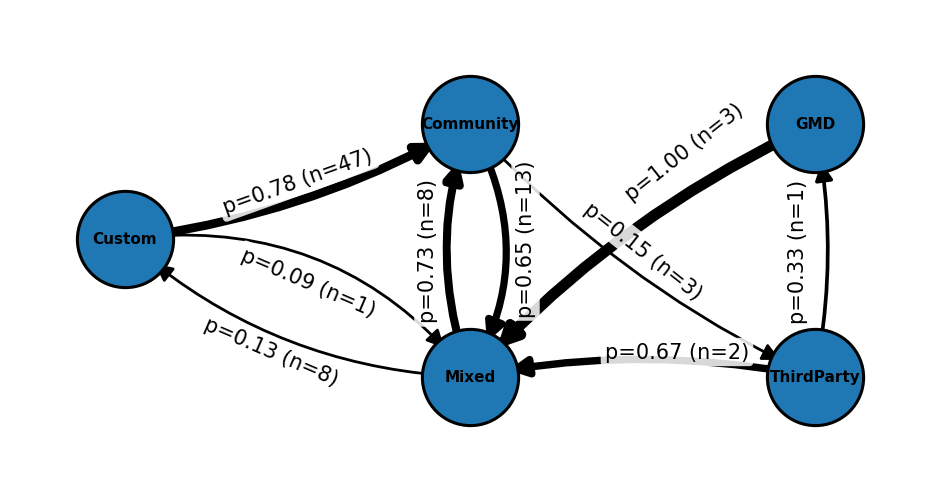

In [10]:
import numpy as np
import matplotlib.pyplot as plt

try:
    import networkx as nx
except ImportError:
    raise SystemExit("Please install networkx (e.g., pip install networkx) to run this script.")

# -----------------------------
# Build graph from computed TOP2
# -----------------------------
G = nx.DiGraph()
G.add_nodes_from(NODES)

for src, edges in TOP2.items():
    for (tgt, p, n) in edges[:2]:
        if p <= 0 or src == tgt:
            continue
        G.add_edge(src, tgt, prob=float(p), count=int(n))

# -----------------------------
# Layout (fixed positions)
# -----------------------------
pos = {
    "Custom": (0.0, 0.0),
    "Community": (1.5, 0.5),
    "Mixed": (1.5, -0.6),
    "GMD": (3.0, 0.5),
    "ThirdParty": (3.0, -0.6),
}
if set(pos.keys()) != set(G.nodes):
    pos = nx.spring_layout(G, seed=7, k=1.0)

# -----------------------------
# Auto curvature for reciprocal pairs (parallel arcs on same side)
# -----------------------------
rad_map = {}
for (u, v) in G.edges:
    if G.has_edge(v, u) and (u, v) not in rad_map and (v, u) not in rad_map:
        rad_map[(u, v)] = -0.28
        rad_map[(v, u)] = -0.18

# -----------------------------
# Figure + padded axes so circles don't clip
# -----------------------------
plt.figure(figsize=(9.5, 5.4))
ax = plt.gca()
ax.set_aspect("equal", adjustable="box")
xs = [xy[0] for xy in pos.values()]
ys = [xy[1] for xy in pos.values()]
PAD_X, PAD_Y = 0.5, 0.5
ax.set_xlim(min(xs) - PAD_X, max(xs) + PAD_X)
ax.set_ylim(min(ys) - PAD_Y, max(ys) + PAD_Y)

# -----------------------------
# Draw edges (first)
# -----------------------------
edge_widths = {e: max(2.0, 8.0 * G[e[0]][e[1]]["prob"]) for e in G.edges}

# Route Custom <-> ThirdParty ABOVE Mixed (gentle arc, no clipping)
special_rad = {}
if G.has_edge("Custom", "ThirdParty"):
    special_rad[("Custom", "ThirdParty")] = +0.35   # left->right: + bends up
if G.has_edge("ThirdParty", "Custom"):
    special_rad[("ThirdParty", "Custom")] = -0.35   # right->left: - bends up


for (u, v) in G.edges:
    nx.draw_networkx_edges(
        G, pos,
        edgelist=[(u, v)],
        arrowstyle="-|>",
        arrowsize=26,
        width=edge_widths[(u, v)],
        connectionstyle=f"arc3,rad={special_rad.get((u, v), rad_map.get((u, v), 0.10))}",
        min_source_margin=20,
        min_target_margin=28,
    )

# Nodes + labels (NO "Community Action" anymore)
nx.draw_networkx_nodes(G, pos, node_size=4800, linewidths=2.2, edgecolors="black")
nx.draw_networkx_labels(G, pos, labels={n: n for n in G.nodes}, font_size=11, font_weight="bold")

# -----------------------------
# Manual edge labels with perpendicular offset + upright text
# -----------------------------
def annotate_edge_label(
    ax, p0, p1, text,
    t=0.5,
    off=0,
    dx=0, dy=0,
    xy=None,
    rot=None,
    follow=True,
    upright=True,          # ✅ keep readable (no upside-down)
    vertical_thresh=80,    # ✅ if |angle| >= this, force +90 (bottom->top)
    **kw
):
    x0, y0 = p0
    x1, y1 = p1

    # Base anchor point
    if xy is None:
        x = (1 - t) * x0 + t * x1
        y = (1 - t) * y0 + t * y1
    else:
        x, y = xy

    # Display-space vectors (for consistent point offsets)
    P0 = ax.transData.transform([x0, y0])
    P1 = ax.transData.transform([x1, y1])
    vx, vy = P1 - P0

    # Perpendicular offset direction
    nx_disp, ny_disp = -vy, vx
    norm = np.hypot(nx_disp, ny_disp)
    if norm == 0:
        perp_dx = perp_dy = 0.0
        angle = 0.0
    else:
        nx_disp /= norm
        ny_disp /= norm
        perp_dx = off * nx_disp
        perp_dy = off * ny_disp

        angle = np.degrees(np.arctan2(vy, vx))

        if upright:
            # wrap to (-180, 180]
            angle = (angle + 180) % 360 - 180

            # keep left-to-right readable: force into [-90, +90]
            if angle > 90:
                angle -= 180
            elif angle < -90:
                angle += 180

            # if it's basically vertical, force bottom->top (+90)
            if abs(angle) >= vertical_thresh:
                angle = 90

    # Rotation choice
    if rot is not None:
        angle_to_use = rot
    elif follow:
        angle_to_use = angle
    else:
        angle_to_use = 0

    dx_pts = perp_dx + dx
    dy_pts = perp_dy + dy

    ax.annotate(
        text,
        xy=(x, y),
        xytext=(dx_pts, dy_pts),
        textcoords="offset points",
        ha="center", va="center",
        rotation=angle_to_use,
        rotation_mode="anchor",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.85),
        **kw,
    )


def edge_text(u, v):
    return f"p={G[u][v]['prob']:.2f} (n={G[u][v]['count']})"

# Optional: keep your custom placements (only applied if that edge exists)
placements = {
    ("Community", "Mixed"): {"t": 0.45, "off": 40},
    ("Mixed", "Community"): {"t": 0.50, "off": +30},

    ("Mixed", "ThirdParty"): {"t": 0.40, "off": -22},
    ("ThirdParty", "Mixed"): {"t": 0.40, "off": -18},

    ("Community", "GMD"): {"t": 0.58, "off": +6},
    ("GMD", "Mixed"): {"t": 0.28, "off": -40},

    ("Custom", "ThirdParty"): {"t": 0.52, "off": -100},


    ("ThirdParty", "GMD"): {"t": 0.50, "off": +12},
    ("GMD", "ThirdParty"): {"t": 0.55, "off": -22},

    ("Custom", "Mixed"): {"t": 0.48, "off": -36},
    ("Mixed", "Custom"): {"t": 0.50, "off": -20},
}


for (u, v) in G.edges:
    p0, p1 = pos[u], pos[v]
    spec = placements.get((u, v), {"t": 0.50, "off": 0, "dx": 0, "dy": 0})

    annotate_edge_label(
        ax, p0, p1, edge_text(u, v),
        t=spec["t"],
        off=spec["off"],     # <-- was offset_pts
        dx=spec.get("dx", 0),
        dy=spec.get("dy", 0),
        xy=spec.get("xy", None),
        rot=spec.get("rot", None),
        follow=spec.get("follow", True),
        fontsize=15,
    )


plt.axis("off")
plt.tight_layout()
plt.show()

# Optional save (rename to RQ2)
# plt.savefig("rq2_state_machine_top2.png", dpi=300, bbox_inches="tight")


In [ ]:
#stacked bar chart

[info] Using episodes CSV: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\ICST2026\2 - RQ2\Observations\List_Change_Episodes.csv
[info] Columns: repo=repo_name, start=episode_start_utc, end=episode_end_utc, styles=env_styles
[info] repos in CSV: 434 (expected 434)
[info] episodes in CSV: 535 (expected 535)
[ok] Wrote CSV: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\ICST2026\2 - RQ2\RQ2_Outputs\rq2_obs_time_buckets_stacked.csv
           Community  Custom   GMD  ThirdParty
bucket                                        
2011-2013       0.00  100.00  0.00        0.00
2014-2016       0.00  100.00  0.00        0.00
2017-2019       0.13   97.25  0.11        2.52
2020-2022      33.18   62.02  0.64        4.16
2023-2025      51.21   39.78  4.13        4.88
[ok] Wrote figure: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\ICST2026\2 - RQ2\RQ2_Outputs\rq2_obs_time_buckets_stacked.png


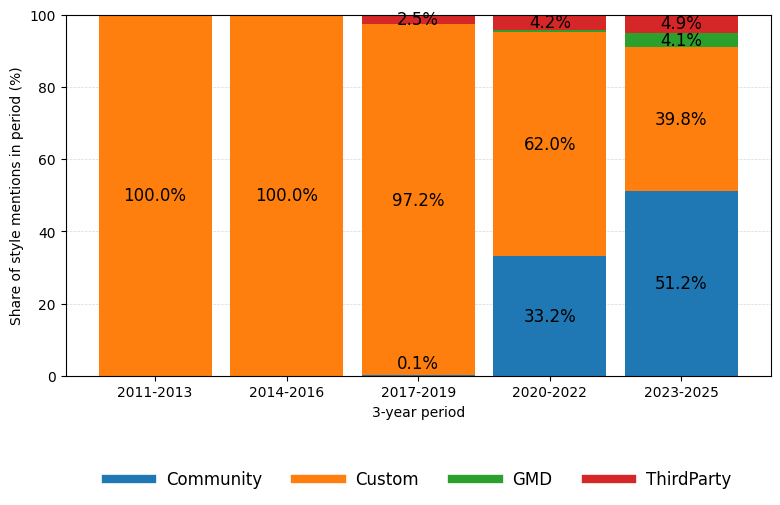

In [24]:
# === Stacked Bar — Presence share (repo/month mentions / total mentions) ===
# Changes requested:
#  1) Forced Community label for early bucket(s) appears at the BOTTOM of the bar.
#  2) Do NOT re-apply 14-day persistence filtering here (episodes CSV already contains retained episodes).

from __future__ import annotations

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ---------- Paths ----------
ROOT = Path(r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\ICST2026")
OBS_DIR = ROOT / "2 - RQ2" / "Observations"

EP_CSV = OBS_DIR / "List_Change_Episodes.csv"
if not EP_CSV.exists() and Path("/mnt/data/List_Change_Episodes.csv").exists():
    EP_CSV = Path("/mnt/data/List_Change_Episodes.csv")

OUT_DIR = ROOT / "2 - RQ2" / "RQ2_Outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_PNG = OUT_DIR / "rq2_obs_time_buckets_stacked.png"
OUT_CSV = OUT_DIR / "rq2_obs_time_buckets_stacked.csv"

print("[info] Using episodes CSV:", EP_CSV)

# ---------- Cutoff (for clipping only) ----------
CUTOFF_ISO = "2025-08-10 23:59:59+00:00"
CUTOFF_DT = pd.to_datetime(CUTOFF_ISO, utc=True, errors="coerce")

# Expected final RQ2 counts (sanity check; only warnings if mismatch)
EXPECTED_REPOS = 434
EXPECTED_EPISODES = 535

# Canonical style tokens as encoded in env_styles / timeline_env_style
STYLES = ("Emu_Community", "Emu_Custom", "GMD", "ThirdParty")
DISPLAY_MAP = {
    "Emu_Community": "Community",
    "Emu_Custom":    "Custom",
    "GMD":           "GMD",
    "ThirdParty":    "ThirdParty",
}
DISPLAY_ORDER = [DISPLAY_MAP[s] for s in STYLES]

# Buckets: start at 2011 (2011–2013, 2014–2016, ..., 2023–2025)
BUCKET_SIZE_YEARS = 3
BUCKET_START_YEAR = 2011

# Labeling: skip tiny slices to avoid overlap (except forced label)
LABEL_MIN_PCT = 2.0

# Force the Community label to be shown at the BOTTOM for these buckets
FORCE_COMMUNITY_BUCKETS = {"2017-2019"}  # add more if desired
FORCE_COMMUNITY_Y = 1.0                  # near bottom (inside bar)
FORCE_COMMUNITY_X_OFFSET = 0.0

# Legend font size
LEGEND_FONT_SIZE = 12

# ---------- Helpers ----------
def pick_col(cols: list[str], candidates: list[str]) -> str | None:
    low = {c.lower(): c for c in cols}
    for c in candidates:
        if c.lower() in low:
            return low[c.lower()]
    for cand in candidates:
        for c in cols:
            if cand.lower() in c.lower():
                return c
    return None

def parse_styleset(cell) -> list[str]:
    """
    Parse env_styles / timeline_env_style into miner tokens:
      - 'Emu_Community+ThirdParty'
      - 'Emu_Custom'
    """
    if cell is None or (isinstance(cell, float) and np.isnan(cell)):
        return []
    s = str(cell).strip()
    if not s or s.lower() in {"nan", "none", "null"}:
        return []
    s2 = s.replace("[", "").replace("]", "").replace("'", "").replace('"', "")

    parts = [s2]
    for sep in ("||", "|", "+", ",", ";", "/"):
        if sep in s2:
            parts = [p.strip() for p in s2.split(sep)]
            break
    parts = [p for p in parts if p]

    keep = []
    for p in parts:
        p = p.strip()
        if p in STYLES:
            keep.append(p)
        # tolerate plain labels if present
        elif p == "Community":
            keep.append("Emu_Community")
        elif p == "Custom":
            keep.append("Emu_Custom")
        elif p == "ThirdParty":
            keep.append("ThirdParty")
        elif p == "GMD":
            keep.append("GMD")
    return sorted(set(keep))

def bucket_label_from_year(year: int) -> str | None:
    if year < BUCKET_START_YEAR:
        return None
    k = (year - BUCKET_START_YEAR) // BUCKET_SIZE_YEARS
    y0 = BUCKET_START_YEAR + k * BUCKET_SIZE_YEARS
    return f"{y0}-{y0+BUCKET_SIZE_YEARS-1}"

def all_bucket_labels_through(end_year: int) -> list[str]:
    labels = []
    y = BUCKET_START_YEAR
    while y <= end_year:
        labels.append(f"{y}-{y+BUCKET_SIZE_YEARS-1}")
        y += BUCKET_SIZE_YEARS
    return labels

# ---------- Load episodes ----------
ep = pd.read_csv(EP_CSV, low_memory=False, encoding="utf-8")
cols = ep.columns.tolist()

repo_col = pick_col(cols, ["repo_name", "full_name", "repo", "repository"])
start_col = pick_col(cols, ["episode_start_utc", "start_utc", "episode_start", "start"])
end_col   = pick_col(cols, ["episode_end_utc", "end_utc", "episode_end", "end"])
style_col = pick_col(cols, ["env_styles", "timeline_env_style", "episode_styleset", "styleset", "style_set"])

if repo_col is None or start_col is None or end_col is None or style_col is None:
    raise ValueError(
        f"Missing required columns in {EP_CSV.name}.\n"
        f"Detected: repo={repo_col}, start={start_col}, end={end_col}, styles={style_col}\n"
        f"Available columns: {cols}"
    )

print(f"[info] Columns: repo={repo_col}, start={start_col}, end={end_col}, styles={style_col}")

# Parse times
ep["_start"] = pd.to_datetime(ep[start_col], utc=True, errors="coerce")
ep["_end"]   = pd.to_datetime(ep[end_col],   utc=True, errors="coerce")
ep = ep[ep[repo_col].notna() & ep["_start"].notna() & ep["_end"].notna()].copy()

# Clip ends to cutoff (safety)
ep["_end"] = ep["_end"].apply(lambda t: min(t, CUTOFF_DT) if pd.notna(t) else t)
ep = ep[ep["_end"] > ep["_start"]].copy()

# Parse style set (episodes already retained/valid — do NOT filter by duration here)
ep["_styles"] = ep[style_col].apply(parse_styleset)
ep["_styles"] = ep["_styles"].apply(lambda xs: sorted(set(x for x in xs if x in STYLES)))
ep = ep[ep["_styles"].map(len) > 0].copy()

# Sanity check against expected released numbers
n_repos = ep[repo_col].nunique()
n_eps = len(ep)
print(f"[info] repos in CSV: {n_repos} (expected {EXPECTED_REPOS})")
print(f"[info] episodes in CSV: {n_eps} (expected {EXPECTED_EPISODES})")
if n_repos != EXPECTED_REPOS or n_eps != EXPECTED_EPISODES:
    print(
        "[warn] Counts differ from released RQ2 numbers.\n"
        f"       expected repos={EXPECTED_REPOS}, episodes={EXPECTED_EPISODES}\n"
        f"       got      repos={n_repos}, episodes={n_eps}\n"
        "       Ensure you're using the paper's List_Change_Episodes.csv export."
    )

# =============================================================================
# Presence share (repo/month mentions / total mentions)
# =============================================================================
rows = []
for _, r in ep.iterrows():
    styles = set(r["_styles"])
    if not styles:
        continue

    start = r["_start"]
    end = r["_end"]

    # inclusive month range for overlap
    end_incl = end - pd.Timedelta(microseconds=1)
    first = pd.Timestamp(start.year, start.month, 1, tz="UTC")
    last  = pd.Timestamp(end_incl.year, end_incl.month, 1, tz="UTC")

    months = pd.date_range(first, last, freq="MS", tz="UTC")
    for m in months:
        row = {"repo_id": r[repo_col], "month": m}
        for sty in STYLES:
            row[sty] = 1 if sty in styles else 0
        rows.append(row)

dfm = pd.DataFrame(rows)
if dfm.empty:
    raise ValueError("No month-level rows produced. Check that your episodes have valid styles and time ranges.")

# repo-month union (presence)
dfm = dfm.groupby(["repo_id", "month"], as_index=False)[list(STYLES)].max()

# map month to bucket
dfm["bucket"] = dfm["month"].dt.year.apply(bucket_label_from_year)
dfm = dfm[dfm["bucket"].notna()].copy()

# sum mentions per bucket
bucket_counts = dfm.groupby("bucket")[list(STYLES)].sum().sort_index()

# keep all buckets (even empty)
all_buckets = all_bucket_labels_through(int(CUTOFF_DT.year))
bucket_counts = bucket_counts.reindex(all_buckets, fill_value=0)

# shares
tot = bucket_counts.sum(axis=1).replace(0, np.nan)
bucket_shares = (bucket_counts.T / tot).T.fillna(0.0) * 100.0
bucket_shares = bucket_shares.rename(columns=DISPLAY_MAP)
bucket_shares = bucket_shares[[c for c in DISPLAY_ORDER if c in bucket_shares.columns]]

bucket_shares.to_csv(OUT_CSV, encoding="utf-8")
print(f"[ok] Wrote CSV: {OUT_CSV}")
print(bucket_shares.round(2))

# ---------- Plot ----------
fig, ax = plt.subplots(figsize=(8, 5))
bucket_shares.plot(kind="bar", stacked=True, ax=ax, width=0.86, edgecolor="none")

ax.set_xlabel("3-year period")
ax.set_ylabel("Share of style mentions in period (%)")
ax.set_ylim(0, 100)
ax.set_xticklabels(bucket_shares.index.tolist(), rotation=0, ha="center")
ax.margins(x=0.015, y=0)
ax.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.5)
ax.set_axisbelow(True)

# Legend proxies with exact bar colors
bar_containers = [c for c in ax.containers if hasattr(c, "patches") and c.patches]
legend_labels = bucket_shares.columns.tolist()
colors = [bc.patches[0].get_facecolor() for bc in bar_containers[:len(legend_labels)]]
proxies = [Line2D([0], [0], color=c, lw=6) for c in colors]

leg = ax.get_legend()
if leg is not None:
    leg.remove()
ax.legend(
    proxies, legend_labels,
    loc="upper center", bbox_to_anchor=(0.5, -0.22),
    ncol=len(legend_labels), frameon=False, handlelength=2.8,
    fontsize=LEGEND_FONT_SIZE
)

# On-bar percent labels (Fix A: skip tiny slices)
for i, bucket in enumerate(bucket_shares.index):
    cum = 0.0
    for sty in legend_labels:
        val = float(bucket_shares.loc[bucket, sty])
        if not np.isfinite(val) or val <= 0.0:
            continue
        if val >= LABEL_MIN_PCT:
            ax.text(i, cum + val / 2.0, f"{val:.1f}%", ha="center", va="center", fontsize=12)
        cum += val

    # Force Community label at the bottom for selected buckets (even if tiny/0.0)
    if bucket in FORCE_COMMUNITY_BUCKETS and "Community" in bucket_shares.columns:
        v_comm = float(bucket_shares.loc[bucket, "Community"])
        ax.text(
            i + FORCE_COMMUNITY_X_OFFSET,
            FORCE_COMMUNITY_Y,
            f"{v_comm:.1f}%",
            ha="center",
            va="bottom",
            fontsize=12
        )

plt.subplots_adjust(bottom=.3)
plt.tight_layout()
plt.savefig(OUT_PNG, dpi=300, bbox_inches="tight")
print(f"[ok] Wrote figure: {OUT_PNG}")
plt.show()
